In [80]:
import os
from xgboost import XGBClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import(
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")

In [81]:
!pip install imbalanced-learn xgboost

In [82]:
df=pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [83]:
df.shape

(265360, 31)

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265360 entries, 0 to 265359
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    265360 non-null  float64
 1   V1      265360 non-null  float64
 2   V2      265360 non-null  float64
 3   V3      265360 non-null  float64
 4   V4      265360 non-null  float64
 5   V5      265359 non-null  float64
 6   V6      265359 non-null  float64
 7   V7      265359 non-null  float64
 8   V8      265359 non-null  float64
 9   V9      265359 non-null  float64
 10  V10     265359 non-null  float64
 11  V11     265359 non-null  float64
 12  V12     265359 non-null  float64
 13  V13     265359 non-null  float64
 14  V14     265359 non-null  float64
 15  V15     265359 non-null  float64
 16  V16     265359 non-null  float64
 17  V17     265359 non-null  float64
 18  V18     265359 non-null  float64
 19  V19     265359 non-null  float64
 20  V20     265359 non-null  float64
 21  V21     26

In [85]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,1
V6,1
V7,1
V8,1
V9,1


In [86]:
missing_rows=df[df.isnull().any(axis=1)]
missing_rows

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
265359,161851.0,2.005486,-0.990444,-0.407233,-0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [87]:
print(df.isnull().sum().sum())

26


In [88]:
total_missing=df.isnull().sum().sum()
total_cells=df.shape[0]*df.shape[1]
missing_percentage=(total_missing/total_cells)*100
print(f"{missing_percentage:.6f}%")

0.000316%


In [89]:
df.loc[19897]

,19897
Time,30633.000000
V1,-2.609841
V2,2.479357
V3,0.763844
V4,0.044509
V5,-0.645716
V6,0.762867
V7,-1.626415
V8,-7.617854
V9,1.399746


In [90]:
df.loc[19897].isnull()

,19897
Time,False
V1,False
V2,False
V3,False
V4,False
V5,False
V6,False
V7,False
V8,False
V9,False


In [91]:
df=df.dropna().copy()

In [92]:
df.shape

(265359, 31)

In [93]:
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
265354,161849.0,1.965498,-0.410602,-0.469883,0.183774,-0.558761,-0.306451,-0.622589,0.067197,1.191429,...,0.256716,0.881651,0.071723,-0.342566,-0.063563,-0.561089,0.052228,-0.045808,10.00,0.0
265355,161850.0,0.041717,0.895154,0.293817,-0.592113,0.452007,-1.101148,1.053337,-0.235284,-0.118808,...,-0.254548,-0.534160,0.067253,0.027309,-0.469420,0.137578,0.249559,0.098485,5.49,0.0
265356,161850.0,-0.578429,0.765023,-0.942130,-0.958078,1.000742,-1.754038,1.759567,-0.474654,-0.102327,...,0.214977,0.859950,-0.140255,0.024740,-0.270721,0.100395,0.520926,0.357215,79.93,0.0
265357,161850.0,-0.360885,1.067309,-0.139529,-0.523392,1.065073,-0.318496,0.848230,0.111054,-0.181236,...,0.078177,0.514656,-0.259133,0.632028,-0.217791,0.531122,0.373266,0.260223,3.79,0.0
265358,161851.0,0.032650,0.901763,0.303674,-0.597897,0.493900,-1.021908,1.050215,-0.221070,-0.149955,...,-0.245706,-0.491968,0.072549,-0.001659,-0.480461,0.141070,0.254167,0.098462,4.99,0.0


In [94]:
print(df.isnull().sum().sum())

0


In [95]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [96]:
df.to_csv("creditcard_cleaned.csv",index=False)
print("Cleaned dataset saved succeefully!")

Cleaned dataset saved succeefully!


In [97]:
print(os.path.exists("creditcard_cleaned.csv"))

True


In [98]:
df["Class"].value_counts()

,count
Class,
0.0,264879
1.0,480


In [99]:
df["Class"].value_counts(normalize=True)*100

,proportion
Class,
0.0,99.819113
1.0,0.180887


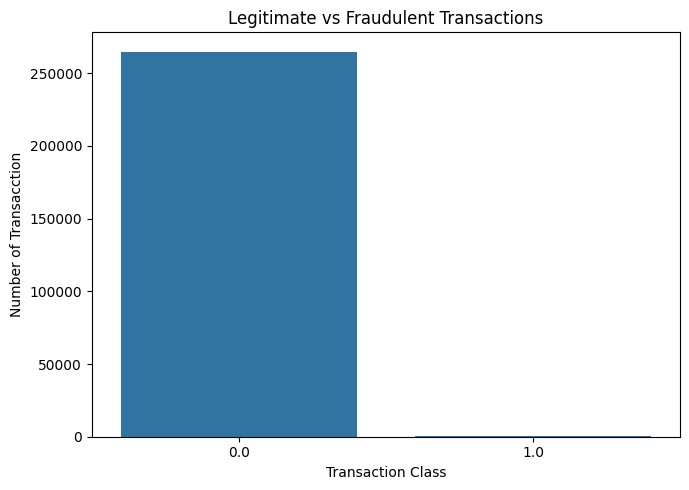

In [100]:
plt.figure(figsize=(7,5))
sns.countplot(
    data=df,
    x="Class"
)
plt.title("Legitimate vs Fraudulent Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transacction")
plt.tight_layout()
plt.savefig(
    "fraud_vs_legitimate.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [101]:
print(df.shape)

(265359, 31)


In [102]:
print("File size:",
      os.path.getsize("creditcard.csv") / (1024 * 1024),
      "MB")

File size: 143.8415069580078 MB


In [103]:
print("first Time:",df["Time"].min())
print("Last Time",df["Time"].max())

first Time: 0.0
Last Time 161851.0


In [104]:
!ls -lh creditcard.csv

-rw-r--r-- 1 root root 144M Sep 27 09:07 creditcard.csv


In [105]:
!ls -lh

total 280M
-rw-r--r-- 1 root root 108K Sep 27 09:04 amount_by_class_log_boxplot.png
-rw-r--r-- 1 root root  96K Sep 27 09:04 amount_distribution_by_class.png
-rw-r--r-- 1 root root 216K Sep 27 09:04 correlation_heatmap.png
-rw-r--r-- 1 root root 135M Sep 27 09:08 creditcard_cleaned.csv
-rw-r--r-- 1 root root 144M Sep 27 09:07 creditcard.csv
-rw-r--r-- 1 root root  90K Sep 27 09:04 fraud_rate_over_time.png
-rw-r--r-- 1 root root  72K Sep 27 09:08 fraud_vs_legitimate.png
-rw-r--r-- 1 root root 142K Sep 27 09:06 precision_recall_curve_comparison.png
-rw-r--r-- 1 root root 165K Sep 27 09:06 roc_curve_comparison.png
drwxr-xr-x 1 root root 4.0K Sep 16 13:26 sample_data
-rw-r--r-- 1 root root 117K Sep 27 09:04 time_distribution_by_class.png


In [106]:
rows=sum(1 for line in open("creditcard.csv"))-1
print("rows in csv:",rows)

rows in csv: 284807


In [107]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0.0,264879.0,89.735848,248.783621,0.0,5.99,22.76,79.00,19656.53
1.0,480.0,121.408896,257.964187,0.0,1.00,8.59,105.08,2125.87


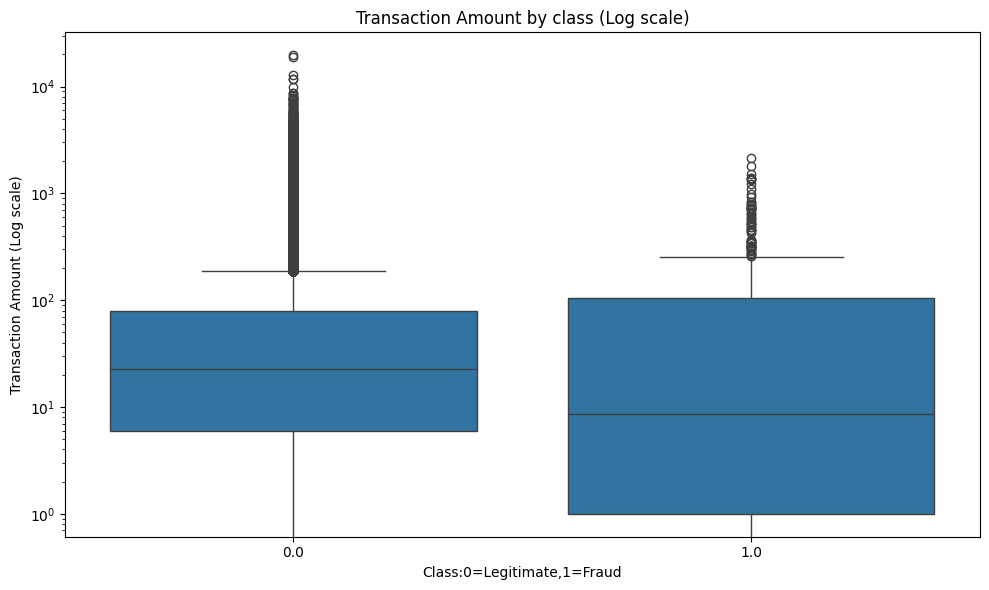

In [108]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)
plt.yscale("log")
plt.title("Transaction Amount by class (Log scale)")
plt.xlabel("Class:0=Legitimate,1=Fraud")
plt.ylabel("Transaction Amount (Log scale)")
plt.tight_layout()
plt.savefig(
    "amount_by_class_log_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

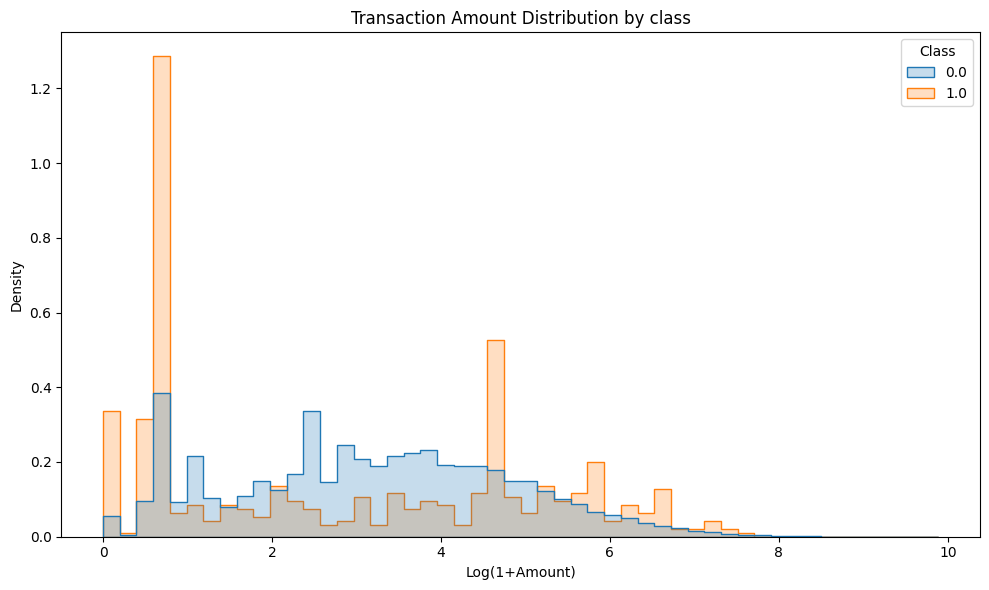

In [109]:
df["LogAmount"]=np.log1p(df["Amount"])
plt.figure(figsize=(10,6))
sns.histplot(
    data=df,
    x="LogAmount",
    hue="Class",
    bins=50,
    element="step",
    stat="density",
    common_norm=False

)
plt.title("Transaction Amount Distribution by class")
plt.xlabel("Log(1+Amount)")
plt.ylabel("Density")
plt.tight_layout()
plt.savefig(
    "amount_distribution_by_class.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [110]:
df["Time"].describe()

,Time
count,265359.000000
mean,89547.197630
std,44872.077786
min,0.000000
25%,52001.000000
50%,80078.000000
75%,132771.500000
max,161851.000000


In [111]:
df.groupby("Class")["Time"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0.0,264879.0,89567.073702,44866.930746,0.0,52027.00,80084.0,132784.00,161851.0
1.0,480.0,78578.960417,46393.444764,406.0,41221.25,72575.5,119261.75,161154.0


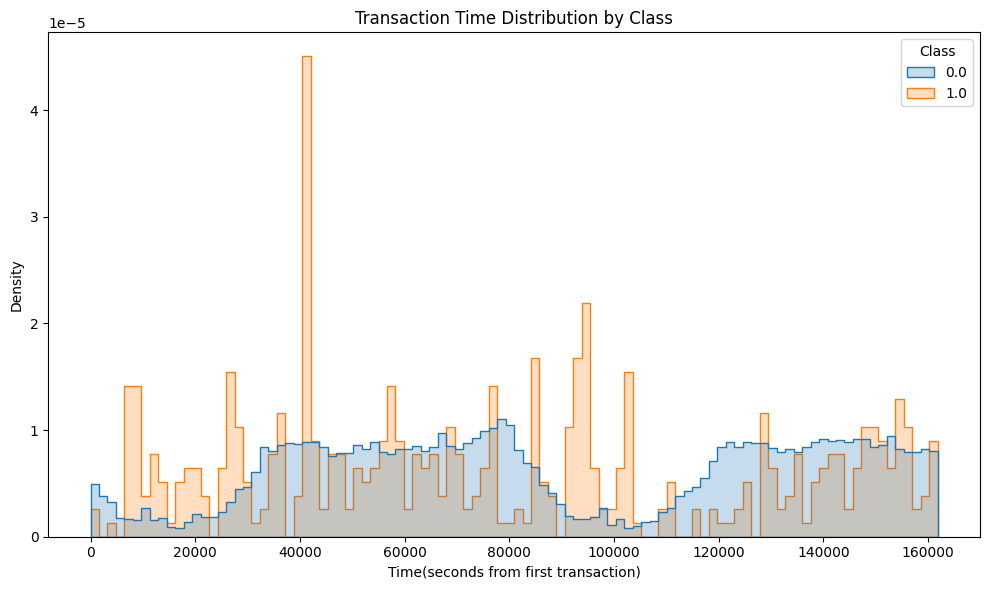

In [112]:
plt.figure(figsize=(10,6))
sns.histplot(
    data=df,
    x="Time",
    hue="Class",
    bins=100,
    element="step",
    stat="density",
    common_norm=False

)
plt.title("Transaction Time Distribution by Class")
plt.xlabel("Time(seconds from first transaction)")
plt.ylabel("Density")
plt.tight_layout()
plt.savefig(
    "time_distribution_by_class.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [113]:
df["Time_hours"]=df["Time"]/3600

In [114]:
df["Time_hours"].describe()

,Time_hours
count,265359.000000
mean,24.874222
std,12.464466
min,0.000000
25%,14.444722
50%,22.243889
75%,36.880972
max,44.958611


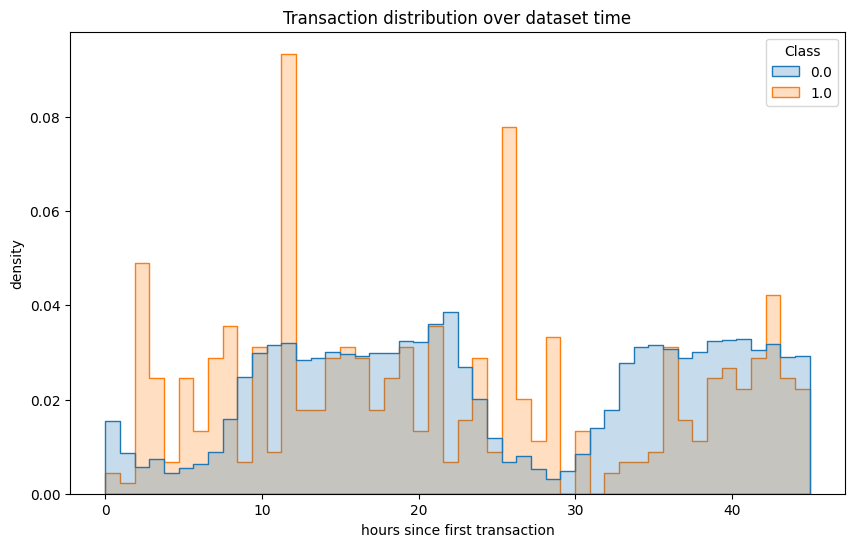

In [115]:
plt.figure(figsize=(10,6))
sns.histplot(
    data=df,
    x="Time_hours",
    hue="Class",
    bins=48,
    element="step",
    stat="density",
    common_norm=False
)
plt.title("Transaction distribution over dataset time")
plt.xlabel("hours since first transaction")
plt.ylabel("density")
plt.savefig(
    "fraud_rate_over_time.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [116]:
correlation_with_class=(
    df.drop(columns=["LogAmount","Time_hours","Time_hour_bin"],errors="ignore")
    .corr()["Class"]
    .sort_values()
)
print(correlation_with_class)

V17      -0.337348
V14      -0.312672
V12      -0.265443
V10      -0.225585
V16      -0.203323
V3       -0.202375
V7       -0.196828
V18      -0.115410
V1       -0.104888
V9       -0.100823
V5       -0.100216
V6       -0.045447
Time     -0.010405
V24      -0.007818
V15      -0.005086
V13      -0.004072
V23      -0.003261
V22       0.000393
V25       0.002818
V26       0.004051
Amount    0.005409
V28       0.009685
V27       0.017364
V20       0.020293
V8        0.021970
V19       0.035648
V21       0.042657
V2        0.095701
V4        0.138216
V11       0.159505
Class     1.000000
Name: Class, dtype: float64


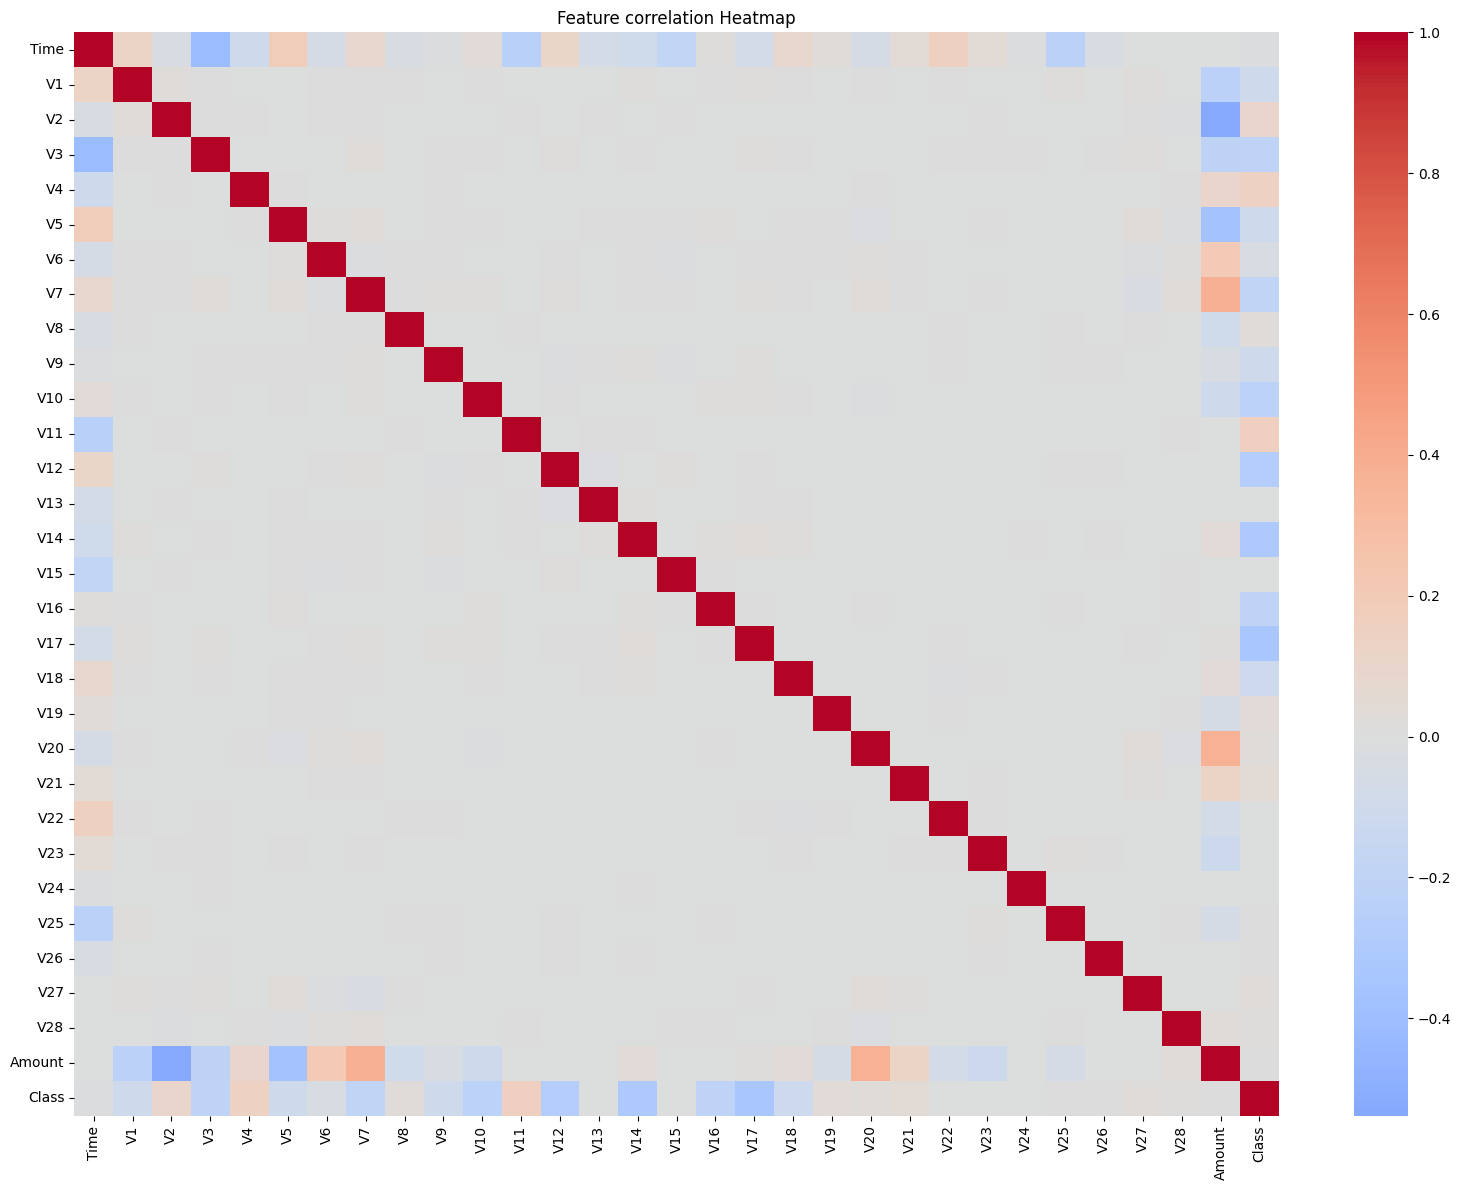

In [117]:
plt.figure(figsize=(16,12))
corr=df[
    ["Time"]+
    [f"V{i}"for i in range(1,29)]+
    ["Amount","Class"]
].corr()
sns.heatmap(
    corr,cmap="coolwarm",
    center=0
)
plt.title("Feature correlation Heatmap")
plt.tight_layout()
plt.savefig(
    "correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [118]:
class_corr=(
    corr['Class']
    .drop("Class")
    .abs()
    .sort_values(ascending=False)
)
print(class_corr.head(10))

V17    0.337348
V14    0.312672
V12    0.265443
V10    0.225585
V16    0.203323
V3     0.202375
V7     0.196828
V11    0.159505
V4     0.138216
V18    0.115410
Name: Class, dtype: float64


In [119]:
df_model=df.copy()
eda_columns=["LogAmount","Time_hours","Time_hour_bin"]
df_model=df_model.drop(
    columns=[col for col in eda_columns if col in df_model.columns]
)
print(df_model.shape)
print(len(df_model.columns))

(265359, 31)
31


In [120]:
"LogAmount"


'LogAmount'

In [121]:
"Time_hours"

'Time_hours'

In [122]:
"Time_hours_bin"

'Time_hours_bin'

In [123]:
x=df_model.drop(columns=["Class"])
y=df_model["Class"]
print(x.shape)
print(y.shape)


(265359, 30)
(265359,)


In [124]:
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(212287, 30)
(53072, 30)
(212287,)
(53072,)


In [125]:
print(y_train.value_counts())
print(y_train.value_counts(normalize=True)*100)
print(y_test.value_counts())
print(y_test.value_counts(normalize=True)*100)

Class
0.0    211903
1.0       384
Name: count, dtype: int64
Class
0.0    99.819113
1.0     0.180887
Name: proportion, dtype: float64
Class
0.0    52976
1.0       96
Name: count, dtype: int64
Class
0.0    99.819114
1.0     0.180886
Name: proportion, dtype: float64


In [126]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [127]:
print(x_train_scaled.mean(axis=0)[:5])
print(x_train_scaled.std(axis=0)[:5])

[-1.27825195e-16  1.13800906e-17 -2.14213471e-18 -3.48096890e-18
 -8.70242225e-19]
[1. 1. 1. 1. 1.]


In [128]:
baseline_model=LogisticRegression(
    max_iter=1000,
    random_state=42
)
baseline_model.fit(x_train_scaled,y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [129]:
y_pred=baseline_model.predict(x_test_scaled)
y_prob=baseline_model.predict_proba(x_test_scaled)[:,1]
print(y_pred[:10])
print(y_prob[:10])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[3.15121187e-04 2.73338307e-04 3.54373101e-04 1.80882841e-04
 8.15707438e-05 2.52341219e-04 2.08653185e-04 1.88197954e-05
 1.92247763e-04 8.23846099e-05]


In [130]:
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred,zero_division=0)
recall=recall_score(y_test,y_pred,zero_division=0)
f1=f1_score(y_test,y_pred,zero_division=0)
roc_auc=roc_auc_score(y_test,y_prob)
pr_auc=average_precision_score(y_test,y_prob)
print(f"Accuracy:{accuracy:.4f}")
print(f"precision:{precision:.4f}")
print(f"recall:{recall:.4f}")
print(f"F1 Score:{f1:.4f}")
print(f"ROC-AUC:{roc_auc:.4f}")
print(f"PR-AUC:{pr_auc:.4f}")

Accuracy:0.9993
precision:0.8642
recall:0.7292
F1 Score:0.7910
ROC-AUC:0.9865
PR-AUC:0.8228


In [131]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[52965    11]
 [   26    70]]


In [132]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Legitimate","Fraud"],
    zero_division=0
))

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     52976
       Fraud       0.86      0.73      0.79        96

    accuracy                           1.00     53072
   macro avg       0.93      0.86      0.90     53072
weighted avg       1.00      1.00      1.00     53072



In [133]:
weighted_model=LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)
weighted_model.fit(x_train_scaled,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [134]:
y_pred_weighted=weighted_model.predict(x_test_scaled)
y_prob_weighted=weighted_model.predict_proba(x_test_scaled)[:,1]


In [135]:
accuracy_weighted=accuracy_score(y_test,y_pred_weighted)
precision_weighted=precision_score(
    y_test,y_pred_weighted,zero_division=0

)
recall_weighted=recall_score(
    y_test,y_pred_weighted,zero_division=0
)
recall_weighted=recall_score(
    y_test,y_pred_weighted,zero_division=0

)
f1_weighted=f1_score(
    y_test,y_pred_weighted,zero_division=0
)
roc_auc_weighted=roc_auc_score(y_test,y_prob_weighted)
pr_auc_weighted=average_precision_score(y_test,y_prob_weighted)
print(f"Accuracy:{accuracy_weighted:.4f}")
print(f"Precision:{precision_weighted:.4f}")
print(f"Recall:{recall_weighted:.4f}")
print(f"F1 score:{f1_weighted:.4f}")
print(f"ROC-AUC:{roc_auc_weighted:.4f}")
print(f"PR-AUC:{pr_auc_weighted:.4f}")

Accuracy:0.9749
Precision:0.0653
Recall:0.9688
F1 score:0.1224
ROC-AUC:0.9888
PR-AUC:0.8101


In [136]:
cm_weighted=confusion_matrix(y_test,y_pred_weighted)
print(cm_weighted)

[[51645  1331]
 [    3    93]]


In [137]:
print(classification_report(
    y_test,
    y_pred_weighted,
    target_names=["Legitimate","Fraud"],
    zero_division=0
))

              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     52976
       Fraud       0.07      0.97      0.12        96

    accuracy                           0.97     53072
   macro avg       0.53      0.97      0.55     53072
weighted avg       1.00      0.97      0.99     53072



In [138]:
comparison=pd.DataFrame({
    "model":["Baseline logistic regression",
    "class-weighted logistic regression"
    ],
    "accuracy":[
        accuracy,
        accuracy_weighted
    ],
    "precision":[
        precision,
        precision_weighted

    ],
    "recall":[
        recall,
        recall_weighted
    ],
    "f1":[
        f1,
        f1_weighted
    ],
    "roc-auc":[
        roc_auc,
        roc_auc_weighted
    ],
    "pr-auc":[
        pr_auc,
        pr_auc_weighted

    ]
})
comparison

,model,accuracy,precision,recall,f1,roc-auc,pr-auc
0,Baseline logistic regression,0.999303,0.864198,0.729167,0.790960,0.986527,0.822793
1,class-weighted logistic regression,0.974864,0.065309,0.968750,0.122368,0.988779,0.810132


In [139]:
smote=SMOTE(
    random_state=42
)
x_train_smote,y_train_smote=smote.fit_resample(
    x_train_scaled,
    y_train
)
print(x_train_scaled.shape)
print(x_train_smote.shape)
print(y_train.value_counts())
print(y_train_smote.value_counts())



(212287, 30)
(423806, 30)
Class
0.0    211903
1.0       384
Name: count, dtype: int64
Class
0.0    211903
1.0    211903
Name: count, dtype: int64


In [140]:
smote_model=LogisticRegression(
    max_iter=1000,
    random_state=42

)
smote_model.fit(
    x_train_smote,
    y_train_smote
)

LogisticRegression(max_iter=1000, random_state=42)

In [141]:
y_pred_smote=smote_model.predict(x_test_scaled)
y_prob_smote=smote_model.predict_proba(x_test_scaled)[:,1]

In [142]:
accuracy_smote=accuracy_score(y_test,y_pred_smote)
precision_smote=precision_score(
    y_test,
    y_pred_smote,
    zero_division=0
)
recall_smote=recall_score(
    y_test,
    y_pred_smote,
    zero_division=0
)
f1_smote=f1_score(
    y_test,
    y_pred_smote,
    zero_division=0
)
roc_auc_smote=roc_auc_score(
    y_test,
    y_prob_smote
)
pr_auc_smote=average_precision_score(
    y_test,
    y_prob_smote
)
print(f"accuracy:{accuracy_smote:.4f}")
print(f"precision:{precision_smote:.4f}")
print(f"recall:{recall_smote:.4f}")
print(f"f1 score:{f1_smote:.4f}")
print(f"roc-auc:{roc_auc_smote:.4f}")
print(f"pr-auc:{pr_auc_smote:.4f}")

accuracy:0.9731
precision:0.0619
recall:0.9792
f1 score:0.1164
roc-auc:0.9892
pr-auc:0.8122


In [143]:
cm_smote=confusion_matrix(
    y_test,
    y_pred_smote
)
print(cm_smote)

[[51551  1425]
 [    2    94]]


In [144]:
print(classification_report(
    y_test,
    y_pred_smote,
    target_names=["Legitimate","Fraud"],
    zero_division=0
))

              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     52976
       Fraud       0.06      0.98      0.12        96

    accuracy                           0.97     53072
   macro avg       0.53      0.98      0.55     53072
weighted avg       1.00      0.97      0.98     53072



In [145]:
comparison=pd.DataFrame({
    "model":[
        "baseline logistic refression",
        "class-weighted logistic regression",
        "smote logistic regression"
    ],
    "accuracy":[
        accuracy,
        accuracy_weighted,
        accuracy_smote
    ],
    "precision":[
        precision,
        precision_weighted,
        precision_smote
    ],
    "recall":[
        recall,
        recall_weighted,
        recall_smote
    ],
    "f1":[
        f1,
        f1_weighted,
        f1_smote
    ],
    "roc-auc":[
        roc_auc,
        roc_auc_weighted,
        roc_auc_smote
    ],
    "pr-auc":[
        pr_auc,
        pr_auc_weighted,
        pr_auc_smote
    ]

})
comparison

,model,accuracy,precision,recall,f1,roc-auc,pr-auc
0,baseline logistic refression,0.999303,0.864198,0.729167,0.790960,0.986527,0.822793
1,class-weighted logistic regression,0.974864,0.065309,0.968750,0.122368,0.988779,0.810132
2,smote logistic regression,0.973112,0.061883,0.979167,0.116409,0.989173,0.812211


In [146]:
negative=(y_train==0).sum()
positive=(y_train==1).sum()
scale_pos_weight=negative/positive
print(negative)
print(positive)
print(scale_pos_weight)

211903
384
551.8307291666666


In [147]:
xgb_model=XGBClassifier(
    n_estimators=300,
    max_depth=4,
    leaning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(
    x_train_scaled,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, leaning_rate=0.05,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, ...)

In [148]:
y_pred_xgb=xgb_model.predict(x_test_scaled)
y_prob_xgb=xgb_model.predict_proba(x_test_scaled)[:,1]

In [149]:
accuracy_xgb=accuracy_score(
    y_test,
    y_pred_xgb
)
precision_xgb=precision_score(
    y_test,
    y_pred_xgb,
    zero_division=0
)
recall_xgb=recall_score(
    y_test,
    y_pred_xgb,
    zero_division=0
)
f1_xgb=f1_score(
    y_test,
    y_pred_xgb,
    zero_division=0
)
roc_auc_xgb=roc_auc_score(
    y_test,
    y_prob_xgb
)
pr_auc_xgb=average_precision_score(
    y_test,
    y_prob_xgb
)
print(f"accuracy:{accuracy_xgb:.4f}")
print(f"precision:{precision_xgb:.4f}")
print(f"recall:{recall_xgb:.4f}")
print(f"f1 score:{f1_xgb:.4f}")
print(f"roc-auc:{roc_auc_xgb:.4f}")
print(f"pr-auc:{pr_auc_xgb:.4f}")

accuracy:0.9996
precision:0.9130
recall:0.8750
f1 score:0.8936
roc-auc:0.9894
pr-auc:0.9238


In [150]:
cm_xgb=confusion_matrix(
    y_test,
    y_pred_xgb
)
print(cm_xgb)

[[52968     8]
 [   12    84]]


In [151]:
print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=["Legitimate", "Fraud"],
    zero_division=0
))

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     52976
       Fraud       0.91      0.88      0.89        96

    accuracy                           1.00     53072
   macro avg       0.96      0.94      0.95     53072
weighted avg       1.00      1.00      1.00     53072



In [152]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Class-Weighted Logistic Regression",
        "SMOTE Logistic Regression",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy,
        accuracy_weighted,
        accuracy_smote,
        accuracy_xgb
    ],
    "Precision": [
        precision,
        precision_weighted,
        precision_smote,
        precision_xgb
    ],
    "Recall": [
        recall,
        recall_weighted,
        recall_smote,
        recall_xgb
    ],
    "F1": [
        f1,
        f1_weighted,
        f1_smote,
        f1_xgb
    ],
    "ROC-AUC": [
        roc_auc,
        roc_auc_weighted,
        roc_auc_smote,
        roc_auc_xgb
    ],
    "PR-AUC": [
        pr_auc,
        pr_auc_weighted,
        pr_auc_smote,
        pr_auc_xgb
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Baseline Logistic Regression,0.999303,0.864198,0.729167,0.790960,0.986527,0.822793
1,Class-Weighted Logistic Regression,0.974864,0.065309,0.968750,0.122368,0.988779,0.810132
2,SMOTE Logistic Regression,0.973112,0.061883,0.979167,0.116409,0.989173,0.812211
3,XGBoost,0.999623,0.913043,0.875000,0.893617,0.989415,0.923754


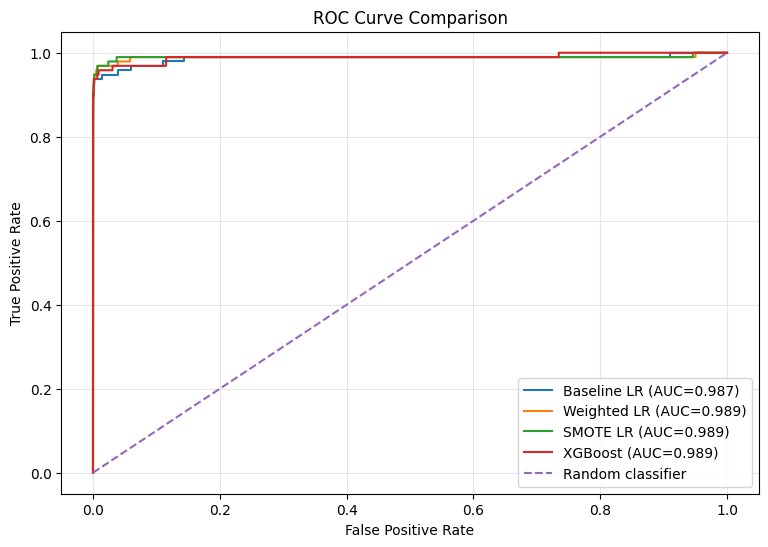

In [153]:

fpr_baseline, tpr_baseline, _ = roc_curve(
    y_test, y_prob
)

fpr_weighted, tpr_weighted, _ = roc_curve(
    y_test, y_prob_weighted
)

fpr_smote, tpr_smote, _ = roc_curve(
    y_test, y_prob_smote
)

fpr_xgb, tpr_xgb, _ = roc_curve(
    y_test, y_prob_xgb
)

# Plot
plt.figure(figsize=(9, 6))

plt.plot(
    fpr_baseline,
    tpr_baseline,
    label=f"Baseline LR (AUC={roc_auc:.3f})"
)

plt.plot(
    fpr_weighted,
    tpr_weighted,
    label=f"Weighted LR (AUC={roc_auc_weighted:.3f})"
)

plt.plot(
    fpr_smote,
    tpr_smote,
    label=f"SMOTE LR (AUC={roc_auc_smote:.3f})"
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC={roc_auc_xgb:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "roc_curve_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

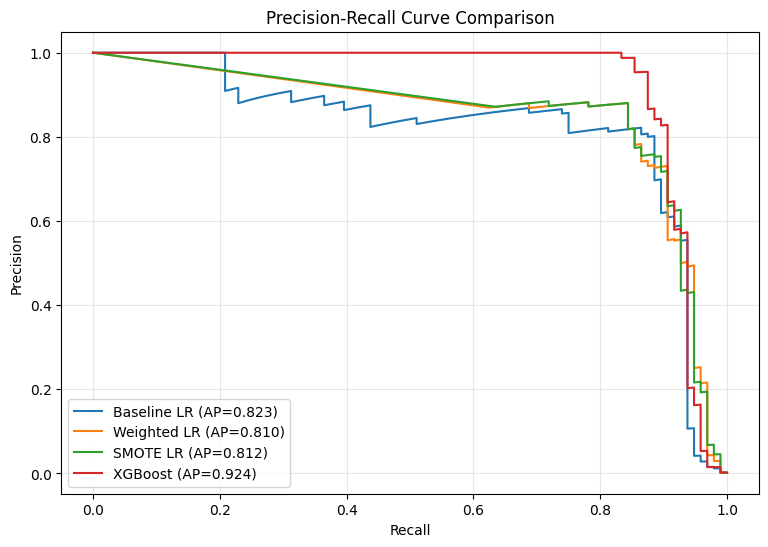

In [154]:

precision_baseline, recall_baseline, _ = precision_recall_curve(
    y_test, y_prob
)

precision_weighted, recall_weighted, _ = precision_recall_curve(
    y_test, y_prob_weighted
)

precision_smote, recall_smote, _ = precision_recall_curve(
    y_test, y_prob_smote
)

precision_xgb, recall_xgb, _ = precision_recall_curve(
    y_test, y_prob_xgb
)

plt.figure(figsize=(9, 6))

plt.plot(
    recall_baseline,
    precision_baseline,
    label=f"Baseline LR (AP={pr_auc:.3f})"
)

plt.plot(
    recall_weighted,
    precision_weighted,
    label=f"Weighted LR (AP={pr_auc_weighted:.3f})"
)

plt.plot(
    recall_smote,
    precision_smote,
    label=f"SMOTE LR (AP={pr_auc_smote:.3f})"
)

plt.plot(
    recall_xgb,
    precision_xgb,
    label=f"XGBoost (AP={pr_auc_xgb:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "precision_recall_curve_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [155]:
y_test
y_prob_xgb

array([2.0557602e-08, 3.1784009e-06, 3.1261462e-07, ..., 1.1070502e-09,
       8.3527169e-08, 7.3128415e-04], dtype=float32)

In [156]:

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

thresholds = np.arange(0.05, 0.96, 0.05)

cost_FN = 500
cost_FP = 25

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (y_prob_xgb >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred_threshold
    ).ravel()

    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    total_cost = (
        fn * cost_FN +
        fp * cost_FP
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn,
        "Cost": total_cost
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1,TP,FP,TN,FN,Cost
0,0.05,0.820755,0.906250,0.861386,87,19,52957,9,4975
1,0.10,0.843137,0.895833,0.868687,86,16,52960,10,5400
2,0.15,0.850000,0.885417,0.867347,85,15,52961,11,5875
3,0.20,0.867347,0.885417,0.876289,85,13,52963,11,5825
4,0.25,0.884211,0.875000,0.879581,84,11,52965,12,6275
5,0.30,0.893617,0.875000,0.884211,84,10,52966,12,6250
6,0.35,0.893617,0.875000,0.884211,84,10,52966,12,6250
7,0.40,0.913043,0.875000,0.893617,84,8,52968,12,6200
8,0.45,0.913043,0.875000,0.893617,84,8,52968,12,6200
9,0.50,0.913043,0.875000,0.893617,84,8,52968,12,6200


In [157]:
best_cost_row = threshold_df.loc[
    threshold_df["Cost"].idxmin()
]

best_cost_row

,0
Threshold,0.050000
Precision,0.820755
Recall,0.906250
F1,0.861386
TP,87.000000
FP,19.000000
TN,52957.000000
FN,9.000000
Cost,4975.000000


In [158]:
print("Lowest-cost threshold:", best_cost_row["Threshold"])
print("Precision:", best_cost_row["Precision"])
print("Recall:", best_cost_row["Recall"])
print("F1:", best_cost_row["F1"])
print("False Positives:", best_cost_row["FP"])
print("False Negatives:", best_cost_row["FN"])
print("Estimated Cost: $", best_cost_row["Cost"])

Lowest-cost threshold: 0.05
Precision: 0.8207547169811321
Recall: 0.90625
F1: 0.8613861386138614
False Positives: 19.0
False Negatives: 9.0
Estimated Cost: $ 4975.0


In [159]:
default_row = threshold_df[
    threshold_df["Threshold"] == 0.50
].iloc[0]

print("Default Threshold: 0.50")
print("--------------------------------")
print("Precision:", default_row["Precision"])
print("Recall:", default_row["Recall"])
print("F1:", default_row["F1"])
print("False Positives:", default_row["FP"])
print("False Negatives:", default_row["FN"])
print("Estimated Cost: $", default_row["Cost"])

Default Threshold: 0.50
--------------------------------
Precision: 0.9130434782608695
Recall: 0.875
F1: 0.8936170212765957
False Positives: 8.0
False Negatives: 12.0
Estimated Cost: $ 6200.0


In [160]:
comparison = pd.DataFrame({
    "Metric": [
        "Threshold",
        "Precision",
        "Recall",
        "F1",
        "False Positives",
        "False Negatives",
        "Estimated Cost"
    ],
    "Default 0.50": [
        default_row["Threshold"],
        default_row["Precision"],
        default_row["Recall"],
        default_row["F1"],
        default_row["FP"],
        default_row["FN"],
        default_row["Cost"]
    ],
    "Lowest Cost": [
        best_cost_row["Threshold"],
        best_cost_row["Precision"],
        best_cost_row["Recall"],
        best_cost_row["F1"],
        best_cost_row["FP"],
        best_cost_row["FN"],
        best_cost_row["Cost"]
    ]
})

comparison

,Metric,Default 0.50,Lowest Cost
0,Threshold,0.500000,0.050000
1,Precision,0.913043,0.820755
2,Recall,0.875000,0.906250
3,F1,0.893617,0.861386
4,False Positives,8.000000,19.000000
5,False Negatives,12.000000,9.000000
6,Estimated Cost,6200.000000,4975.000000


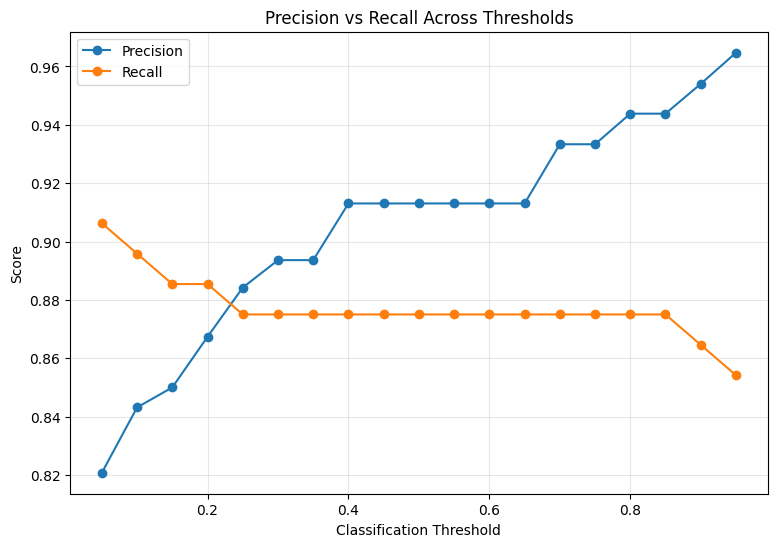

In [161]:


plt.figure(figsize=(9, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall Across Thresholds")

plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "threshold_precision_recall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

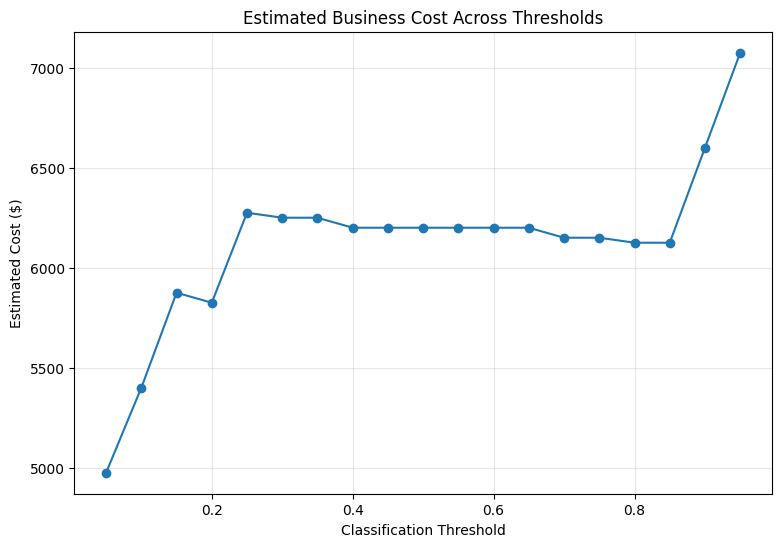

In [162]:
plt.figure(figsize=(9, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Cost"],
    marker="o"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Estimated Cost ($)")
plt.title("Estimated Business Cost Across Thresholds")

plt.grid(alpha=0.3)

plt.savefig(
    "threshold_business_cost.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [163]:
threshold_display = threshold_df[
    [
        "Threshold",
        "Precision",
        "Recall",
        "F1",
        "FP",
        "FN",
        "Cost"
    ]
].copy()

threshold_display["Precision"] = (
    threshold_display["Precision"] * 100
).round(2)

threshold_display["Recall"] = (
    threshold_display["Recall"] * 100
).round(2)

threshold_display["F1"] = (
    threshold_display["F1"] * 100
).round(2)

threshold_display["Cost"] = (
    threshold_display["Cost"]
).round(2)

threshold_display

,Threshold,Precision,Recall,F1,FP,FN,Cost
0,0.05,82.08,90.62,86.14,19,9,4975
1,0.10,84.31,89.58,86.87,16,10,5400
2,0.15,85.00,88.54,86.73,15,11,5875
3,0.20,86.73,88.54,87.63,13,11,5825
4,0.25,88.42,87.50,87.96,11,12,6275
5,0.30,89.36,87.50,88.42,10,12,6250
6,0.35,89.36,87.50,88.42,10,12,6250
7,0.40,91.30,87.50,89.36,8,12,6200
8,0.45,91.30,87.50,89.36,8,12,6200
9,0.50,91.30,87.50,89.36,8,12,6200


In [164]:
threshold_df.to_csv(
    "threshold_analysis.csv",
    index=False
)

In [165]:


feature_importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
14,V14,0.452606
10,V10,0.115834
4,V4,0.065930
12,V12,0.035926
17,V17,0.033401
8,V8,0.028500
20,V20,0.024171
29,Amount,0.022328
11,V11,0.022289
19,V19,0.021372


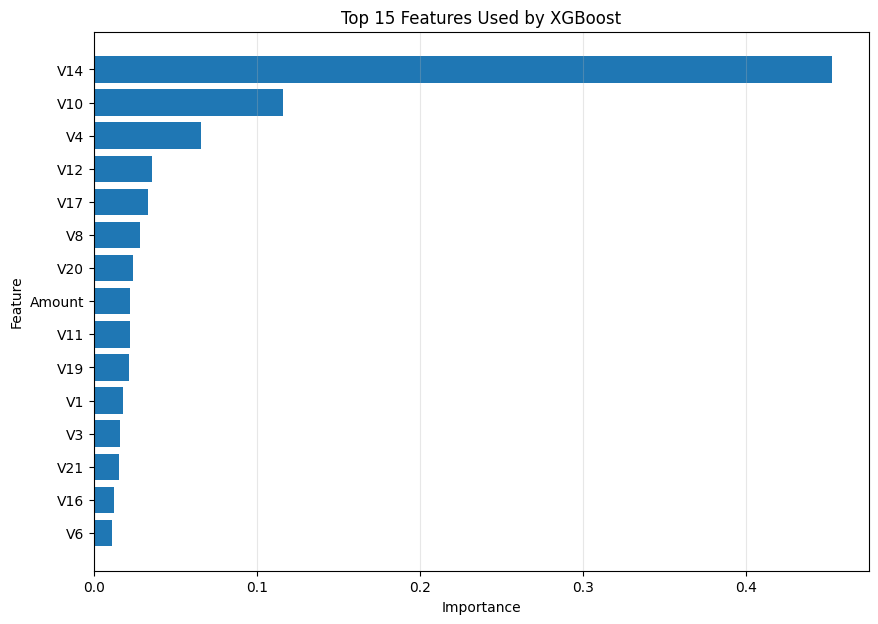

In [166]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features Used by XGBoost")

plt.grid(
    axis="x",
    alpha=0.3
)

plt.savefig(
    "xgboost_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [167]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    xgb_model,
    x_test_scaled,
    y_test,
    scoring="average_precision",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

In [168]:
permutation_df = pd.DataFrame({
    "Feature": x_test.columns,
    "Importance_Mean": perm_result.importances_mean,
    "Importance_Std": perm_result.importances_std
})

permutation_df = permutation_df.sort_values(
    by="Importance_Mean",
    ascending=False
)

permutation_df.head(15)

,Feature,Importance_Mean,Importance_Std
14,V14,0.095878,0.012291
4,V4,0.039857,0.006026
3,V3,0.020452,0.004465
10,V10,0.018923,0.001574
11,V11,0.018123,0.005892
12,V12,0.011790,0.003704
1,V1,0.011066,0.005031
29,Amount,0.009101,0.001562
26,V26,0.006804,0.002612
28,V28,0.004506,0.003017


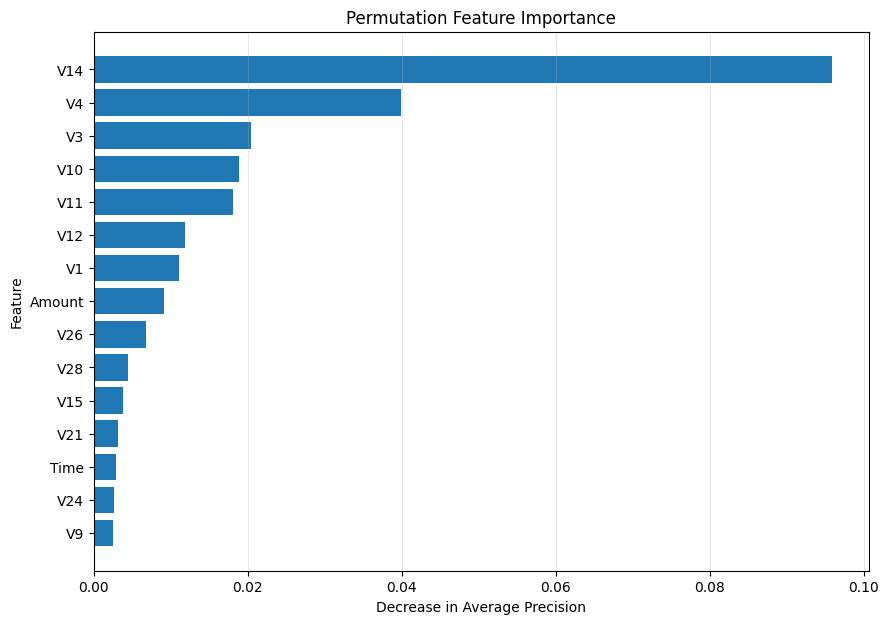

In [169]:
top_permutation = permutation_df.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_permutation["Feature"][::-1],
    top_permutation["Importance_Mean"][::-1]
)

plt.xlabel("Decrease in Average Precision")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance")

plt.grid(
    axis="x",
    alpha=0.3
)

plt.savefig(
    "permutation_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [170]:
feature_importance.to_csv(
    "xgboost_feature_importance.csv",
    index=False
)

permutation_df.to_csv(
    "permutation_feature_importance.csv",
    index=False
)

In [171]:
production_threshold = float(best_cost_row["Threshold"])

print("Production threshold:", production_threshold)

Production threshold: 0.05


In [172]:
production_threshold = 0.50

In [173]:

os.makedirs("models", exist_ok=True)

print("Models folder created.")

Models folder created.


In [174]:
import joblib

joblib.dump(
    xgb_model,
    "models/fraud_model.joblib"
)

print("Fraud model saved successfully.")

Fraud model saved successfully.


In [175]:
os.listdir("models")

['fraud_model.joblib']

In [176]:
feature_names = list(x_train.columns)

joblib.dump(
    feature_names,
    "models/feature_names.joblib"
)

print("Number of features:", len(feature_names))
print(feature_names)

Number of features: 30
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [177]:
X_input = df[feature_names]

In [178]:
print(type(roc_auc_xgb), roc_auc_xgb)
print(type(pr_auc_xgb), pr_auc_xgb)
print(type(precision_xgb), precision_xgb)
print(type(recall_xgb), recall_xgb)
print(type(f1_xgb), f1_xgb)
print(type(accuracy_xgb), accuracy_xgb)

<class 'numpy.float64'> 0.9894150181214135
<class 'numpy.float64'> 0.9237535553031012
<class 'numpy.ndarray'> [0.00180886 0.0018089  0.00180893 ... 1.         1.         1.        ]
<class 'numpy.ndarray'> [1.         1.         1.         ... 0.15625    0.08333333 0.        ]
<class 'float'> 0.8936170212765957
<class 'float'> 0.9996231534519143


In [179]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

accuracy_xgb_final = accuracy_score(
    y_test,
    y_pred_xgb
)

precision_xgb_final = precision_score(
    y_test,
    y_pred_xgb,
    zero_division=0
)

recall_xgb_final = recall_score(
    y_test,
    y_pred_xgb,
    zero_division=0
)

f1_xgb_final = f1_score(
    y_test,
    y_pred_xgb,
    zero_division=0
)

roc_auc_xgb_final = roc_auc_score(
    y_test,
    y_prob_xgb
)

pr_auc_xgb_final = average_precision_score(
    y_test,
    y_prob_xgb
)

print("XGBoost Metrics")
print("----------------------")
print(f"Accuracy:  {accuracy_xgb_final:.6f}")
print(f"Precision: {precision_xgb_final:.6f}")
print(f"Recall:    {recall_xgb_final:.6f}")
print(f"F1 Score:  {f1_xgb_final:.6f}")
print(f"ROC-AUC:   {roc_auc_xgb_final:.6f}")
print(f"PR-AUC:    {pr_auc_xgb_final:.6f}")

XGBoost Metrics
----------------------
Accuracy:  0.999623
Precision: 0.913043
Recall:    0.875000
F1 Score:  0.893617
ROC-AUC:   0.989415
PR-AUC:    0.923754


In [180]:
production_threshold = float(best_cost_row["Threshold"])

print("Production threshold:", production_threshold)

Production threshold: 0.05


In [181]:
model_metadata = {
    "model_name": "XGBoost",

    "threshold": production_threshold,

    "cost_false_negative": 500,
    "cost_false_positive": 25,

    "accuracy": float(accuracy_xgb_final),
    "precision": float(precision_xgb_final),
    "recall": float(recall_xgb_final),
    "f1": float(f1_xgb_final),
    "roc_auc": float(roc_auc_xgb_final),
    "pr_auc": float(pr_auc_xgb_final),

    "n_features": len(feature_names),
    "feature_names": feature_names
}

joblib.dump(
    model_metadata,
    "models/model_metadata.joblib"
)

print("Model metadata saved successfully.")

Model metadata saved successfully.


In [182]:
loaded_metadata = joblib.load(
    "models/model_metadata.joblib"
)

print(loaded_metadata)

{'model_name': 'XGBoost', 'threshold': 0.05, 'cost_false_negative': 500, 'cost_false_positive': 25, 'accuracy': 0.9996231534519143, 'precision': 0.9130434782608695, 'recall': 0.875, 'f1': 0.8936170212765957, 'roc_auc': 0.9894150181214135, 'pr_auc': 0.9237535553031012, 'n_features': 30, 'feature_names': ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']}


In [183]:
loaded_model = joblib.load(
    "models/fraud_model.joblib"
)

loaded_features = joblib.load(
    "models/feature_names.joblib"
)

loaded_metadata = joblib.load(
    "models/model_metadata.joblib"
)

In [184]:
print("Model:", type(loaded_model))
print("Number of features:", len(loaded_features))
print("Threshold:", loaded_metadata["threshold"])
print("Model name:", loaded_metadata["model_name"])

Model: <class 'xgboost.sklearn.XGBClassifier'>
Number of features: 30
Threshold: 0.05
Model name: XGBoost


In [185]:
sample_transaction = x_test.iloc[[0]]

sample_probability = loaded_model.predict_proba(
    sample_transaction
)[:, 1][0]

sample_prediction = int(
    sample_probability >= loaded_metadata["threshold"]
)

print("Fraud probability:", sample_probability)
print("Prediction:", sample_prediction)

Fraud probability: 1.0708376e-08
Prediction: 0


In [186]:
def get_risk_level(probability):

    if probability < 0.30:
        return "Low"

    elif probability < 0.70:
        return "Medium"

    elif probability < 0.90:
        return "High"

    else:
        return "Critical"

In [187]:
print(get_risk_level(0.12))
print(get_risk_level(0.45))
print(get_risk_level(0.78))
print(get_risk_level(0.95))

Low
Medium
High
Critical


In [188]:
def get_recommended_action(probability, threshold):

    if probability < threshold:
        return "Approve"

    elif probability < 0.90:
        return "Review Manually"

    else:
        return "Temporarily Block"

In [189]:
threshold = loaded_metadata["threshold"]

print(get_recommended_action(0.20, threshold))
print(get_recommended_action(0.65, threshold))
print(get_recommended_action(0.95, threshold))

Review Manually
Review Manually
Temporarily Block


In [190]:
from xgboost import XGBClassifier
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("Negative samples:", negative)
print("Positive samples:", positive)
print("Scale pos weight:", scale_pos_weight)

production_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

production_model.fit(
    x_train,
    y_train
)

print("Production XGBoost model trained successfully.")

Negative samples: 211903
Positive samples: 384
Scale pos weight: 551.8307291666666
Production XGBoost model trained successfully.


In [191]:
y_pred_production = production_model.predict(x_test)

y_prob_production = production_model.predict_proba(
    x_test
)[:, 1]

In [192]:

production_accuracy = accuracy_score(
    y_test,
    y_pred_production
)

production_precision = precision_score(
    y_test,
    y_pred_production,
    zero_division=0
)

production_recall = recall_score(
    y_test,
    y_pred_production,
    zero_division=0
)

production_f1 = f1_score(
    y_test,
    y_pred_production,
    zero_division=0
)

production_roc_auc = roc_auc_score(
    y_test,
    y_prob_production
)

production_pr_auc = average_precision_score(
    y_test,
    y_prob_production
)

print("FINAL PRODUCTION MODEL")
print("=" * 35)

print(f"Accuracy:  {production_accuracy:.6f}")
print(f"Precision: {production_precision:.6f}")
print(f"Recall:    {production_recall:.6f}")
print(f"F1 Score:  {production_f1:.6f}")
print(f"ROC-AUC:   {production_roc_auc:.6f}")
print(f"PR-AUC:    {production_pr_auc:.6f}")

FINAL PRODUCTION MODEL
Accuracy:  0.999001
Precision: 0.656934
Recall:    0.937500
F1 Score:  0.772532
ROC-AUC:   0.993979
PR-AUC:    0.931371


In [193]:
production_threshold = loaded_metadata["threshold"]

y_pred_threshold = (
    y_prob_production >= production_threshold
).astype(int)

In [194]:


tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred_threshold
).ravel()

print("Production Threshold:", production_threshold)
print()
print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

Production Threshold: 0.05

True Negatives : 52067
False Positives: 909
False Negatives: 3
True Positives  : 93


In [195]:
sample_transaction = x_test.iloc[[0]]

probability = production_model.predict_proba(
    sample_transaction
)[:, 1][0]

prediction = int(
    probability >= production_threshold
)

risk = get_risk_level(probability)

action = get_recommended_action(
    probability,
    production_threshold
)

print("Fraud Probability:", f"{probability:.2%}")
print("Prediction:", prediction)
print("Risk Level:", risk)
print("Recommended Action:", action)

Fraud Probability: 0.04%
Prediction: 0
Risk Level: Low
Recommended Action: Approve


In [196]:
joblib.dump(
    production_model,
    "models/fraud_model.joblib"
)

print("Final production model saved.")

Final production model saved.


In [197]:
model_metadata = {
    "model_name": "XGBoost",

    "threshold": production_threshold,

    "cost_false_negative": 500,
    "cost_false_positive": 25,

    "accuracy": float(production_accuracy),
    "precision": float(production_precision),
    "recall": float(production_recall),
    "f1": float(production_f1),
    "roc_auc": float(production_roc_auc),
    "pr_auc": float(production_pr_auc),

    "n_features": len(feature_names),
    "feature_names": feature_names
}

joblib.dump(
    model_metadata,
    "models/model_metadata.joblib"
)

print("Production metadata updated.")

Production metadata updated.


In [198]:


print("models/")
for file in os.listdir("models"):
    print("  ├──", file)

models/
  ├── feature_names.joblib
  ├── model_metadata.joblib
  ├── fraud_model.joblib


In [199]:

final_model = joblib.load(
    "models/fraud_model.joblib"
)

final_features = joblib.load(
    "models/feature_names.joblib"
)

final_metadata = joblib.load(
    "models/model_metadata.joblib"
)

transaction = x_test.iloc[[0]]

probability = final_model.predict_proba(
    transaction[final_features]
)[:, 1][0]

threshold = final_metadata["threshold"]

risk = get_risk_level(probability)

action = get_recommended_action(
    probability,
    threshold
)

print("FraudShield AI Production Test")
print("=" * 40)
print(f"Fraud Probability : {probability:.2%}")
print(f"Threshold         : {threshold:.2f}")
print(f"Risk Level        : {risk}")
print(f"Recommended Action: {action}")

FraudShield AI Production Test
Fraud Probability : 0.04%
Threshold         : 0.05
Risk Level        : Low
Recommended Action: Approve


In [200]:
import os

folders = [
    "fraudshield-ai",
    "fraudshield-ai/models",
    "fraudshield-ai/data",
    "fraudshield-ai/notebooks",
    "fraudshield-ai/src",
    "fraudshield-ai/assets"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("FraudShield AI project structure created.")

FraudShield AI project structure created.


In [201]:
for root, dirs, files in os.walk("fraudshield-ai"):
    level = root.replace("fraudshield-ai", "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

fraudshield-ai/
    data/
    assets/
    models/
    notebooks/
    src/


In [202]:
import shutil

source_files = [
    "models/fraud_model.joblib",
    "models/feature_names.joblib",
    "models/model_metadata.joblib"
]

for source in source_files:
    destination = os.path.join(
        "fraudshield-ai",
        source
    )

    shutil.copy2(source, destination)

print("Production model files copied.")

Production model files copied.


In [203]:
!pip install -q streamlit plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 85.3 MB/s eta 0:00:00


In [204]:
import streamlit
import plotly

print("Streamlit:", streamlit.__version__)
print("Plotly:", plotly.__version__)

Streamlit: 1.64.0
Plotly: 5.24.1


In [205]:
%%writefile fraudshield-ai/app.py

import streamlit as st
import joblib
import pandas as pd
import plotly.graph_objects as go
from pathlib import Path

st.set_page_config(
    page_title="FraudShield AI",
    page_icon="🛡️",
    layout="wide",
    initial_sidebar_state="expanded"
)


BASE_DIR = Path(__file__).resolve().parent

MODEL_PATH = BASE_DIR / "models" / "fraud_model.joblib"
FEATURE_PATH = BASE_DIR / "models" / "feature_names.joblib"
METADATA_PATH = BASE_DIR / "models" / "model_metadata.joblib"

@st.cache_resource
def load_model():

    model = joblib.load(MODEL_PATH)

    return model


@st.cache_data
def load_features():

    features = joblib.load(FEATURE_PATH)

    return features


@st.cache_data
def load_metadata():

    metadata = joblib.load(METADATA_PATH)

    return metadata


model = load_model()
feature_names = load_features()
metadata = load_metadata()

st.markdown(
    """
    <style>

    .stApp {
        background-color: #0B1220;
    }

    .main-title {
        font-size: 58px;
        font-weight: 800;
        color: white;
        margin-bottom: 10px;
    }

    .subtitle {
        font-size: 21px;
        color: #B8C2D1;
        line-height: 1.6;
        max-width: 750px;
    }

    .accent {
        color: #2F80ED;
    }

    .metric-card {
        background-color: #121C2E;
        padding: 25px;
        border-radius: 15px;
        border: 1px solid #25324A;
        text-align: center;
    }

    .metric-number {
        font-size: 32px;
        font-weight: 700;
        color: white;
    }

    .metric-label {
        font-size: 14px;
        color: #9AA7BA;
        margin-top: 5px;
    }

    .section-title {
        color: white;
        font-size: 32px;
        font-weight: 700;
        margin-top: 50px;
        margin-bottom: 20px;
    }

    .feature-card {
        background-color: #121C2E;
        padding: 25px;
        border-radius: 15px;
        border: 1px solid #25324A;
        min-height: 180px;
    }

    .feature-title {
        color: white;
        font-size: 20px;
        font-weight: 700;
    }

    .feature-text {
        color: #AEB9C9;
        line-height: 1.6;
    }

    .footer {
        text-align: center;
        color: #718096;
        padding: 40px 0 20px 0;
        font-size: 13px;
    }

    </style>
    """,
    unsafe_allow_html=True
)


st.sidebar.title("🛡️ FraudShield AI")

st.sidebar.markdown(
    """
    **AI-powered transaction risk analysis**

    Navigate through the application using the options below.
    """
)

page = st.sidebar.radio(
    "Navigation",
    [
        "Home",
        "Fraud Detection",
        "Batch Analysis",
        "Model Performance",
        "Threshold Simulator",
        "About"
    ]
)


if page == "Home":

    st.markdown(
        '<div class="main-title">'
        'Detect Fraud. <span class="accent">Protect Every Transaction.</span>'
        '</div>',
        unsafe_allow_html=True
    )

    st.markdown(
        """
        <div class="subtitle">
        FraudShield AI uses machine learning to identify suspicious
        credit-card transactions and provide actionable risk signals
        for fraud and payment teams.
        </div>
        """,
        unsafe_allow_html=True
    )

    st.write("")

    col1, col2 = st.columns([1, 1])

    with col1:

        if st.button(
            "🔍 Try Fraud Detection",
            use_container_width=True
        ):
            st.session_state["page"] = "Fraud Detection"
            st.rerun()

    with col2:

        if st.button(
            "📊 View Model Insights",
            use_container_width=True
        ):
            st.session_state["page"] = "Model Performance"
            st.rerun()

    st.markdown(
        '<div class="section-title">Model Snapshot</div>',
        unsafe_allow_html=True
    )

    col1, col2, col3, col4 = st.columns(4)

    with col1:
        st.metric(
            "Model ROC-AUC",
            f"{metadata['roc_auc']:.3f}"
        )

    with col2:
        st.metric(
            "PR-AUC",
            f"{metadata['pr_auc']:.3f}"
        )

    with col3:
        st.metric(
            "Fraud Recall",
            f"{metadata['recall']:.1%}"
        )

    with col4:
        st.metric(
            "Features",
            metadata["n_features"]
        )

    st.markdown(
        '<div class="section-title">How FraudShield AI Works</div>',
        unsafe_allow_html=True
    )

    col1, col2, col3 = st.columns(3)

    with col1:
        st.markdown(
            """
            <div class="feature-card">
                <div class="feature-title">
                1. Submit
                </div>
                <p class="feature-text">
                Enter a transaction or upload a CSV file
                containing transaction data.
                </p>
            </div>
            """,
            unsafe_allow_html=True
        )

    with col2:
        st.markdown(
            """
            <div class="feature-card">
                <div class="feature-title">
                2. Analyze
                </div>
                <p class="feature-text">
                FraudShield AI evaluates the transaction
                using the trained XGBoost fraud detection model.
                </p>
            </div>
            """,
            unsafe_allow_html=True
        )

    with col3:
        st.markdown(
            """
            <div class="feature-card">
                <div class="feature-title">
                3. Review
                </div>
                <p class="feature-text">
                Receive a fraud probability, risk level,
                and suggested action.
                </p>
            </div>
            """,
            unsafe_allow_html=True
        )


    st.markdown(
        '<div class="section-title">Built for Fraud Risk Decisions</div>',
        unsafe_allow_html=True
    )

    col1, col2, col3, col4 = st.columns(4)

    benefits = [
        (
            "🎯",
            "Risk Scoring",
            "Convert transaction data into a fraud probability."
        ),
        (
            "📈",
            "Model Insights",
            "Review performance using precision, recall, ROC-AUC and PR-AUC."
        ),
        (
            "⚙️",
            "Configurable Threshold",
            "Adjust the decision threshold according to business costs."
        ),
        (
            "💰",
            "Cost Analysis",
            "Explore the financial effect of false positives and missed fraud."
        )
    ]

    for col, (icon, title, description) in zip(
        [col1, col2, col3, col4],
        benefits
    ):

        with col:

            st.markdown(
                f"""
                <div class="feature-card">
                    <div style="font-size:30px;">
                    {icon}
                    </div>

                    <div class="feature-title">
                    {title}
                    </div>

                    <p class="feature-text">
                    {description}
                    </p>
                </div>
                """,
                unsafe_allow_html=True
            )


    st.markdown(
        """
        <div class="footer">
        FraudShield AI is an educational and portfolio demonstration.
        It is not a production banking fraud prevention system and
        should not be used as the sole basis for financial decisions.
        </div>
        """,
        unsafe_allow_html=True
    )

Writing fraudshield-ai/app.py


In [206]:
%cd fraudshield-ai

/content/fraudshield-ai


In [207]:
!streamlit run app.py &>/content/streamlit.log &

In [208]:
!cat /content/streamlit.log

In [209]:
%%writefile /content/fraudshield-ai/app.py

print("Hello FraudShield AI")

Overwriting /content/fraudshield-ai/app.py


In [210]:
import os

print(os.path.exists("/content/fraudshield-ai/app.py"))

True


In [212]:
import joblib

model_test = joblib.load("models/fraud_model.joblib")

print(type(model_test))
print("Colab model loads successfully!")

<class 'xgboost.sklearn.XGBClassifier'>
Colab model loads successfully!


In [213]:
from google.colab import files

files.download("models/fraud_model.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [214]:
import joblib

model = joblib.load("models/fraud_model.joblib")

print("MODEL LOADED")
print(type(model))

MODEL LOADED
<class 'xgboost.sklearn.XGBClassifier'>


In [215]:
import sys
import xgboost
import joblib

print("Python:", sys.version)
print("XGBoost:", xgboost.__version__)
print("Joblib:", joblib.__version__)

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
XGBoost: 3.4.1
Joblib: 1.6.0


In [216]:
import xgboost as xgb
import joblib

# Load the working model in Colab
model = joblib.load("models/fraud_model.joblib")

# Save it in XGBoost's portable model format
model.save_model("models/fraud_model.json")

print("JSON model saved successfully!")

JSON model saved successfully!


In [217]:
model.save_model("model.json")

In [218]:
model.load_model("model.json")

In [219]:
from xgboost import XGBClassifier

test_model = XGBClassifier()
test_model.load_model("models/fraud_model.json")

print(type(test_model))
print("JSON MODEL LOADS SUCCESSFULLY!")

<class 'xgboost.sklearn.XGBClassifier'>
JSON MODEL LOADS SUCCESSFULLY!


In [220]:
from google.colab import files

files.download("models/fraud_model.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [222]:
fraud_row = df[df["Class"] == 1].iloc[0]

fraud_row

,541
Time,406.000000
V1,-2.312227
V2,1.951992
V3,-1.609851
V4,3.997906
V5,-0.522188
V6,-1.426545
V7,-2.537387
V8,1.391657
V9,-2.770089


In [223]:
print(fraud_row.to_dict())


{'Time': 406.0, 'V1': -2.3122265423263, 'V2': 1.95199201064158, 'V3': -1.60985073229769, 'V4': 3.9979055875468, 'V5': -0.522187864667764, 'V6': -1.42654531920595, 'V7': -2.53738730624579, 'V8': 1.39165724829804, 'V9': -2.77008927719433, 'V10': -2.77227214465915, 'V11': 3.20203320709635, 'V12': -2.89990738849473, 'V13': -0.595221881324605, 'V14': -4.28925378244217, 'V15': 0.389724120274487, 'V16': -1.14074717980657, 'V17': -2.83005567450437, 'V18': -0.0168224681808257, 'V19': 0.416955705037907, 'V20': 0.126910559061474, 'V21': 0.517232370861764, 'V22': -0.0350493686052974, 'V23': -0.465211076182388, 'V24': 0.320198198514526, 'V25': 0.0445191674731724, 'V26': 0.177839798284401, 'V27': 0.261145002567677, 'V28': -0.143275874698919, 'Amount': 0.0, 'Class': 1.0, 'LogAmount': 0.0, 'Time_hours': 0.11277777777777778}


In [224]:
legitimate_row = df[df["Class"] == 0].iloc[0]

print(legitimate_row.to_dict())

{'Time': 0.0, 'V1': -1.3598071336738, 'V2': -0.0727811733098497, 'V3': 2.53634673796914, 'V4': 1.37815522427443, 'V5': -0.338320769942518, 'V6': 0.462387777762292, 'V7': 0.239598554061257, 'V8': 0.0986979012610507, 'V9': 0.363786969611213, 'V10': 0.0907941719789316, 'V11': -0.551599533260813, 'V12': -0.617800855762348, 'V13': -0.991389847235408, 'V14': -0.311169353699879, 'V15': 1.46817697209427, 'V16': -0.470400525259478, 'V17': 0.207971241929242, 'V18': 0.0257905801985591, 'V19': 0.403992960255733, 'V20': 0.251412098239705, 'V21': -0.018306777944153, 'V22': 0.277837575558899, 'V23': -0.110473910188767, 'V24': 0.0669280749146731, 'V25': 0.128539358273528, 'V26': -0.189114843888824, 'V27': 0.133558376740387, 'V28': -0.0210530534538215, 'Amount': 149.62, 'Class': 0.0, 'LogAmount': 5.014760108673205, 'Time_hours': 0.0}


In [226]:
fraud_test_row = x_test[y_test == 1].iloc[0]

print(fraud_test_row)

Time      76857.000000
V1            1.140208
V2            1.156431
V3           -1.471578
V4            2.076278
V5            0.774809
V6           -1.002532
V7            0.264948
V8            0.013162
V9            0.248835
V10          -2.100667
V11           0.763205
V12          -0.944916
V13          -1.419034
V14          -4.683620
V15           0.519282
V16           0.908454
V17           4.133667
V18           1.306205
V19          -1.094716
V20          -0.125097
V21          -0.387895
V22          -0.866812
V23          -0.121583
V24          -0.356109
V25           0.634573
V26          -0.306311
V27           0.094087
V28           0.121065
Amount        1.000000
Name: 123238, dtype: float64


In [227]:
legitimate_test_row = x_test[y_test == 0].iloc[0]

print(legitimate_test_row)

Time      67063.000000
V1           -1.376953
V2            1.410598
V3            1.229332
V4            0.882212
V5           -0.522084
V6            0.691385
V7           -0.475260
V8            1.135110
V9           -0.639270
V10          -0.623382
V11           0.634600
V12           1.270812
V13           0.231145
V14           0.524975
V15          -0.353118
V16          -0.294166
V17           0.395743
V18          -0.135916
V19           0.935682
V20          -0.246601
V21          -0.129601
V22          -0.582132
V23          -0.046661
V24          -0.327032
V25           0.241808
V26          -0.492020
V27          -0.460524
V28          -0.153599
Amount       12.990000
Name: 99315, dtype: float64


In [228]:
fraud_probability = xgb_model.predict_proba(
    fraud_test_row.to_frame().T
)[0][1]

print("Fraud probability:", fraud_probability)

Fraud probability: 0.49365464


In [229]:
legitimate_probability = xgb_model.predict_proba(
    legitimate_test_row.to_frame().T
)[0][1]

print("Legitimate row fraud probability:", legitimate_probability)

Legitimate row fraud probability: 1.0708376e-08


In [231]:
test_samples = x_test.copy()

test_samples["Class"] = y_test

test_samples.head(10).to_csv(
    "fraudshield_test_transactions.csv",
    index=False
)

print("Saved successfully!")

Saved successfully!


In [232]:
from google.colab import files

files.download("fraudshield_test_transactions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>